In [112]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [113]:
df=pd.read_csv('AAPL (4).csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,03-01-2012,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,04-01-2012,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,05-01-2012,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,06-01-2012,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,09-01-2012,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [114]:
df.shape

(2011, 7)

# Data Processing

In [115]:
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [116]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 110.1+ KB


In [118]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [119]:
df.duplicated().sum()

0

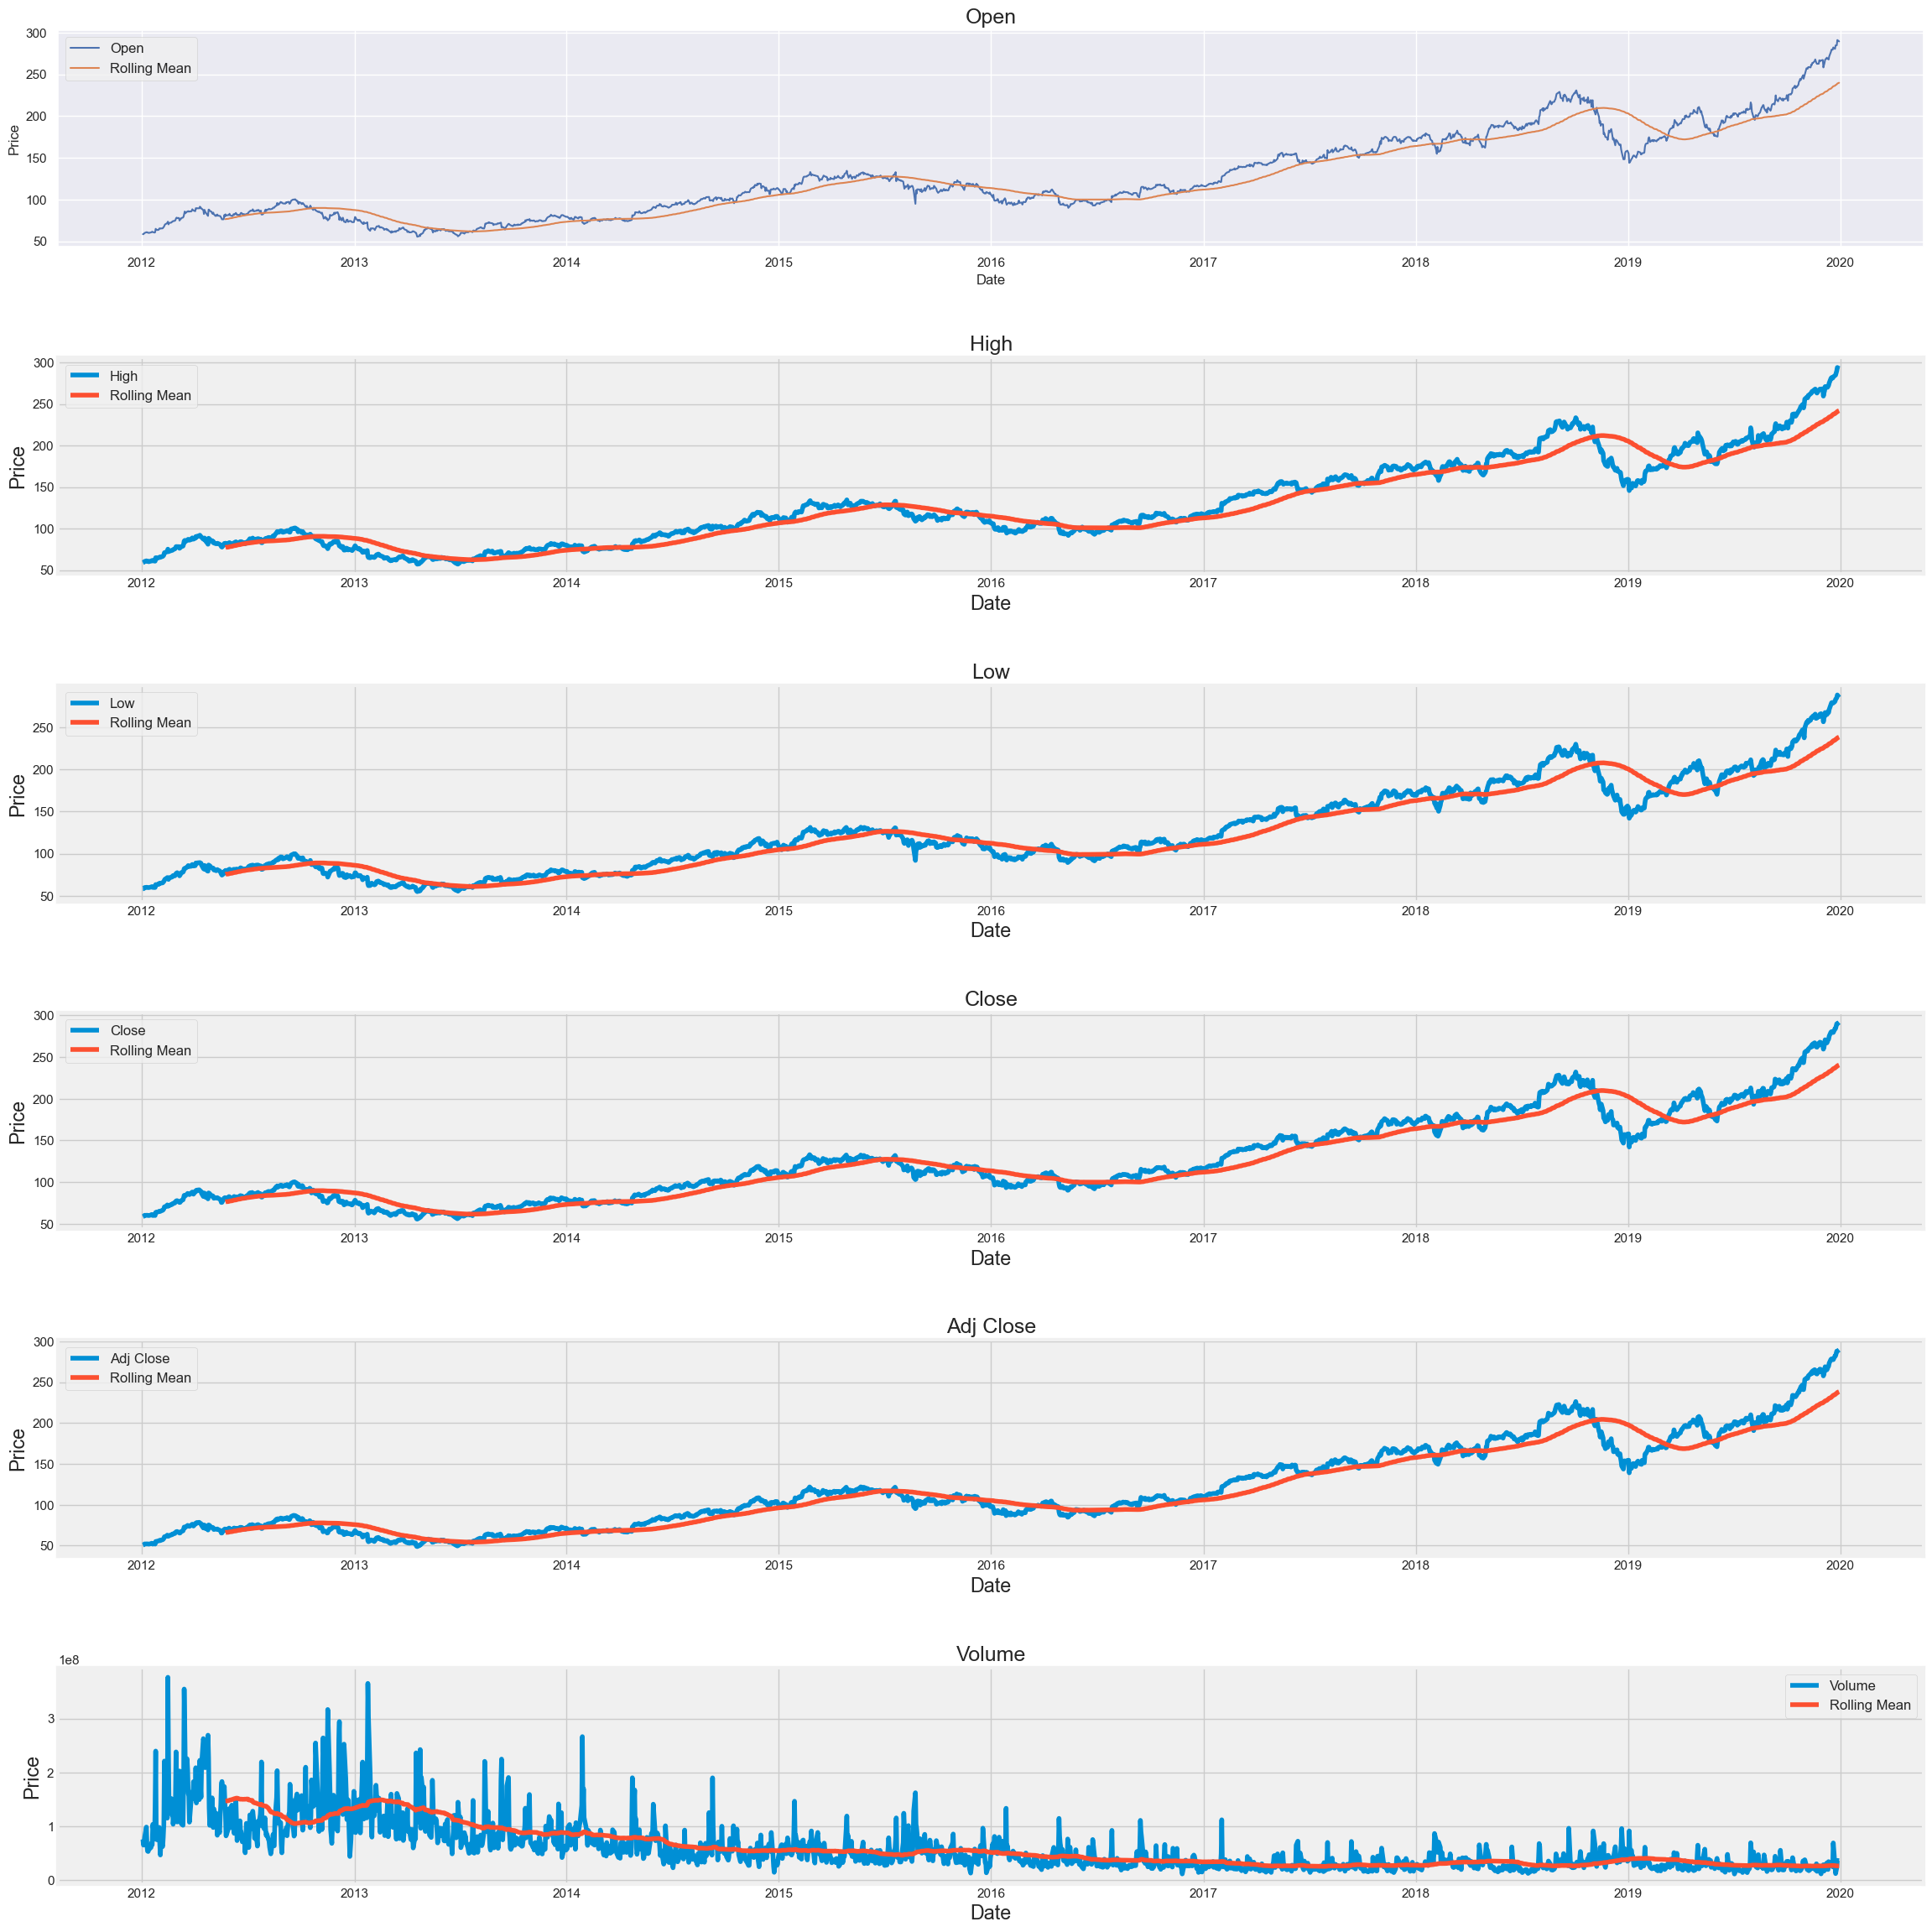

In [120]:
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], dayfirst=True)
col_names = df.columns

fig = plt.figure(figsize=(24, 24))

# Plot columns 1 to 6, assuming they are numeric
for i in range(1, 7):
    ax = fig.add_subplot(6, 1, i)
    ax.plot(df.iloc[:, 0], df.iloc[:, i], label=col_names[i])
    ax.plot(df.iloc[:, 0], df.iloc[:, i].rolling(100).mean(), label='Rolling Mean')

    ax.set_title(col_names[i], fontsize=18)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.patch.set_edgecolor('black')
    plt.style.use('fivethirtyeight')
    ax.legend(prop={'size': 12})

fig.tight_layout(pad=3.0)
plt.show()

### Inference from rolling mean of each column
The rolling mean analysis shows a clear upward trend in all price-related columns Open, High, Low, Close, and Adjusted Close — indicating consistent long-term growth. A noticeable dip around 2019–2020 is observed across these metrics, followed by a strong recovery. In contrast, Volume displays significant volatility, especially during 2020, likely due to increased trading activity amid the COVID-19 pandemic.

# Feature Selection

In [121]:
correlation_matrix =df.iloc[:, 1:].corr()
correlation_matrix

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999782,0.999718,0.999496,0.998895,-0.557956
High,0.999782,1.000000,0.999657,0.999748,0.999171,-0.554909
Low,0.999718,0.999657,1.000000,0.999769,0.999179,-0.563426
Close,0.999496,0.999748,0.999769,1.000000,0.999402,-0.559654
Adj Close,0.998895,0.999171,0.999179,0.999402,1.000000,-0.566332
Volume,-0.557956,-0.554909,-0.563426,-0.559654,-0.566332,1.000000


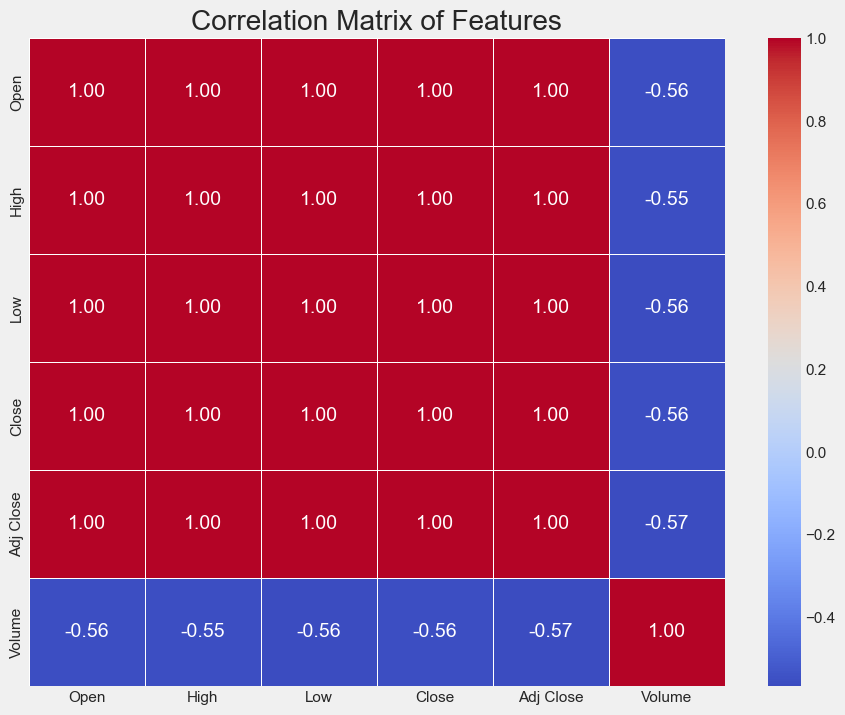

In [122]:
# Display the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()


In [123]:
##Data after feature selection
data_selected = df.drop(axis=1,labels=['Date','Open','High','Low','Adj Close','Volume'])

In [124]:
data_selected

,Close
0,58.747143
1,59.062859
2,59.718571
3,60.342857
4,60.247143
...,...
2006,284.000000
2007,284.269989
2008,289.910004
2009,289.799988


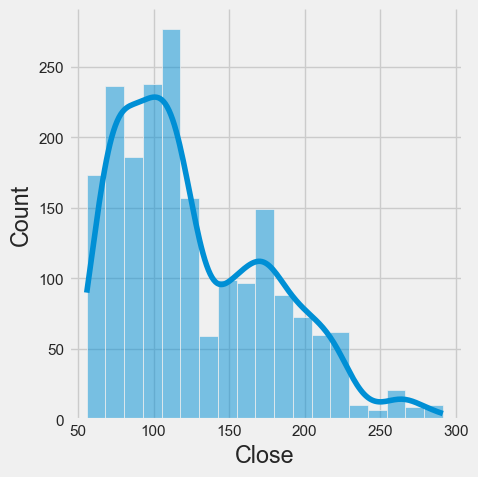

In [125]:
sns.displot(data_selected["Close"], kde='True')

#### Above graph shows that the Close figure is approximate around 300

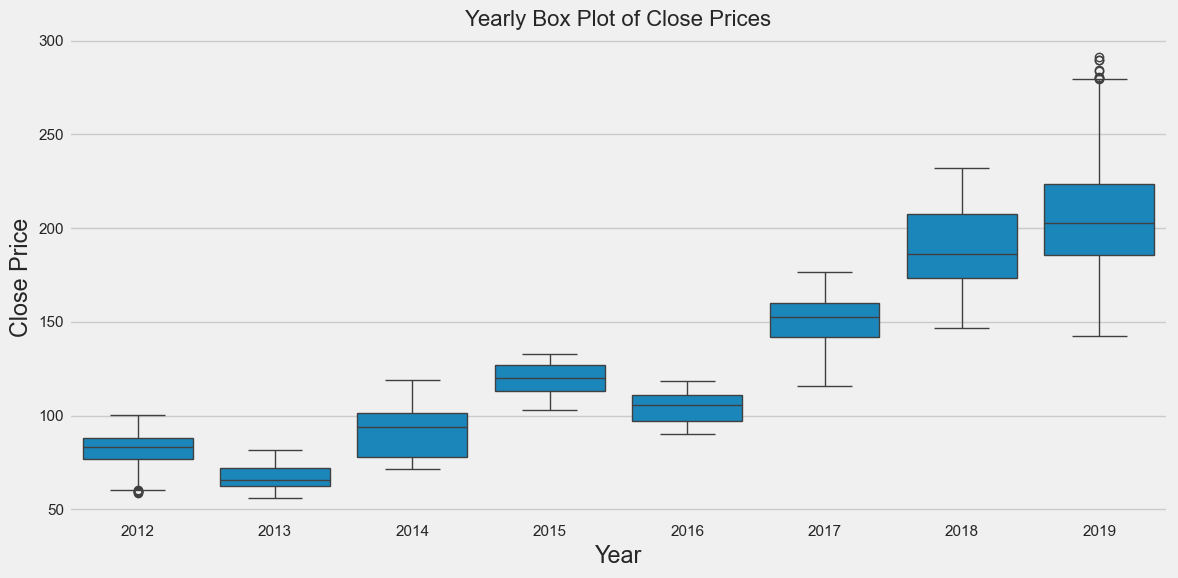

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract year from the Date column
df['Year'] = df['Date'].dt.year

# Plot boxplot grouped by Year
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='Year', y='Close', data=df, ax=ax)
plt.title("Yearly Box Plot of Close Prices", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.tight_layout()
plt.show()

### The box plot shows a steady increase in the median Close Price from 2012 to 2018, followed by a rapid surge in 2019. This indicates strong growth momentum, with 2019 also exhibiting higher price volatility and more outliers, reflecting increased market activity.

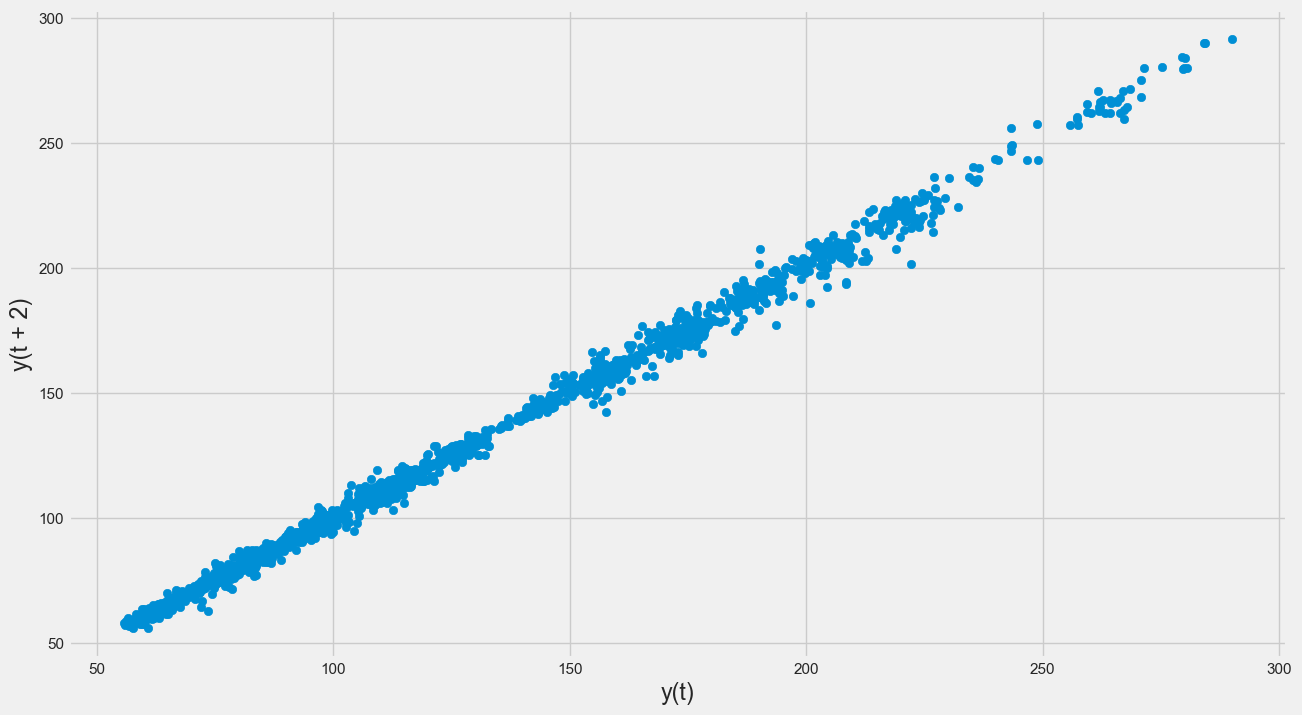

In [127]:
from pandas.plotting import lag_plot
plt.figure(figsize=(14, 8))
lag_plot(data_selected['Close'], lag=2)
plt.show()

### As clustered along a diagonal line, it suggests a linear correlation between the current value of the series and the value from two time steps back.

# Resampling

In [128]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [129]:
monthly_data = df.resample('M').mean()

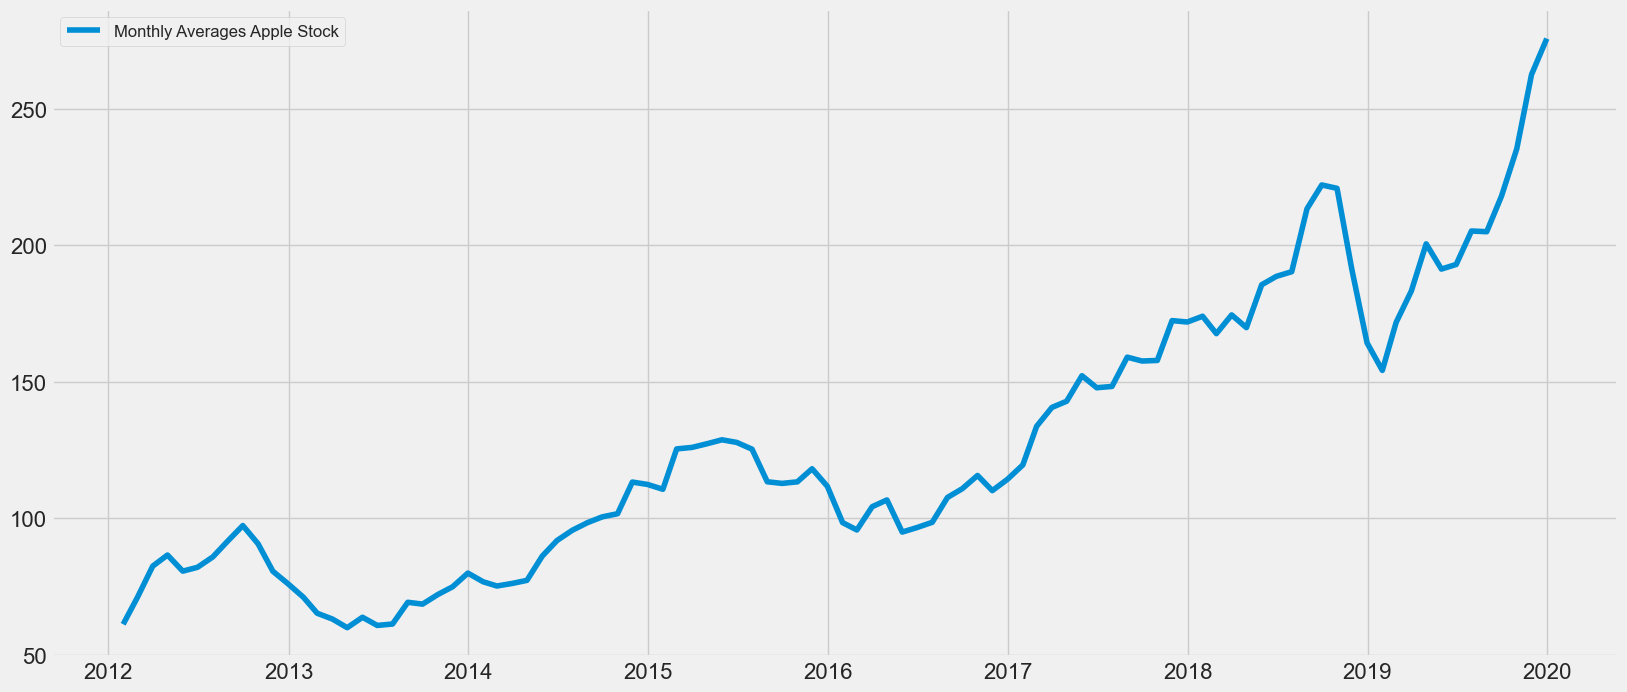

In [130]:
##Monthly Stock Price 
fig = plt.figure(figsize=(18,8))
plt.plot(monthly_data['Close'],label='Monthly Averages Apple Stock')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.set_title('Monthly Resampled Data')
plt.style.use('fivethirtyeight')
plt.legend(prop={'size': 12})
plt.show()

(array([0.   , 0.002, 0.004, 0.006, 0.008, 0.01 ]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.002, '0.002'),
  Text(0, 0.004, '0.004'),
  Text(0, 0.006, '0.006'),
  Text(0, 0.008, '0.008'),
  Text(0, 0.01, '0.010')])

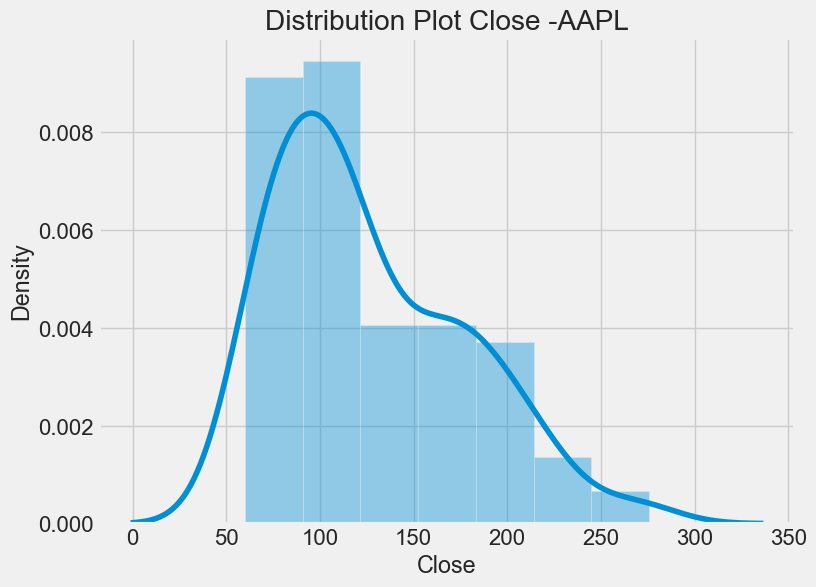

In [131]:
##Checking Distribution of Our Data 
fig = plt.figure(figsize=(8,6))
sns.distplot(monthly_data['Close']).set_title("Distribution Plot Close -AAPL")
ax.tick_params(labelsize=12)
sns.set(font_scale=1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#### Above distribution shows slightly right skewed

# Decomposition of Time Series

<Figure size 2000x1600 with 0 Axes>

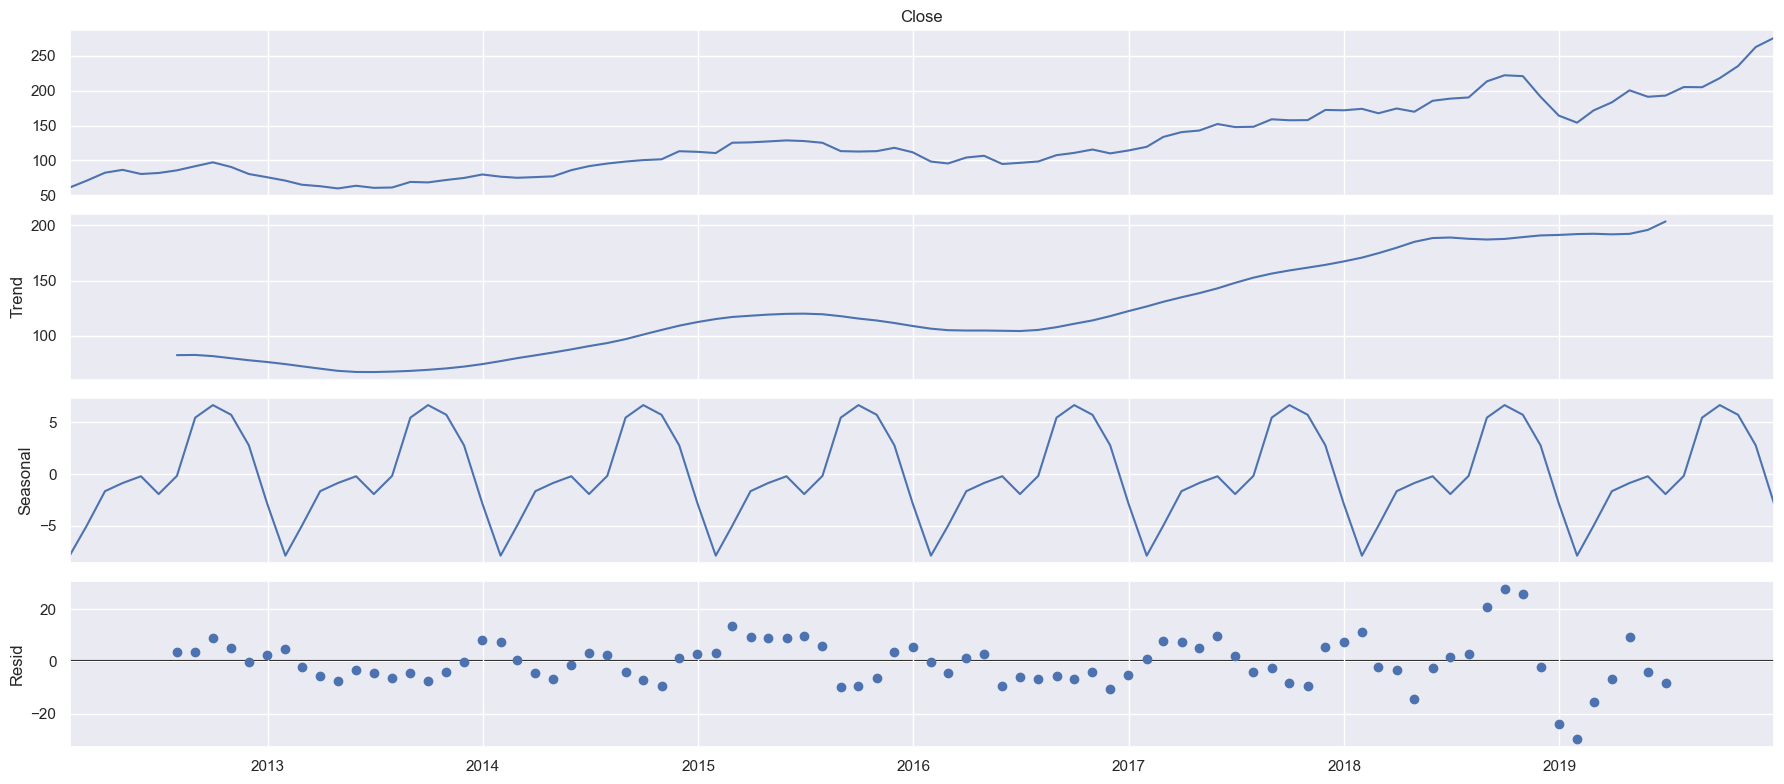

In [132]:
from pylab import rcParams
from statsmodels.tsa.seasonal import seasonal_decompose as sd
rcParams['figure.figsize'] = 18, 8
plt.figure(figsize=(20,16))
decomposed_series = sd(monthly_data['Close'],model='additive',period=12)
decomposed_series.plot()
plt.show()

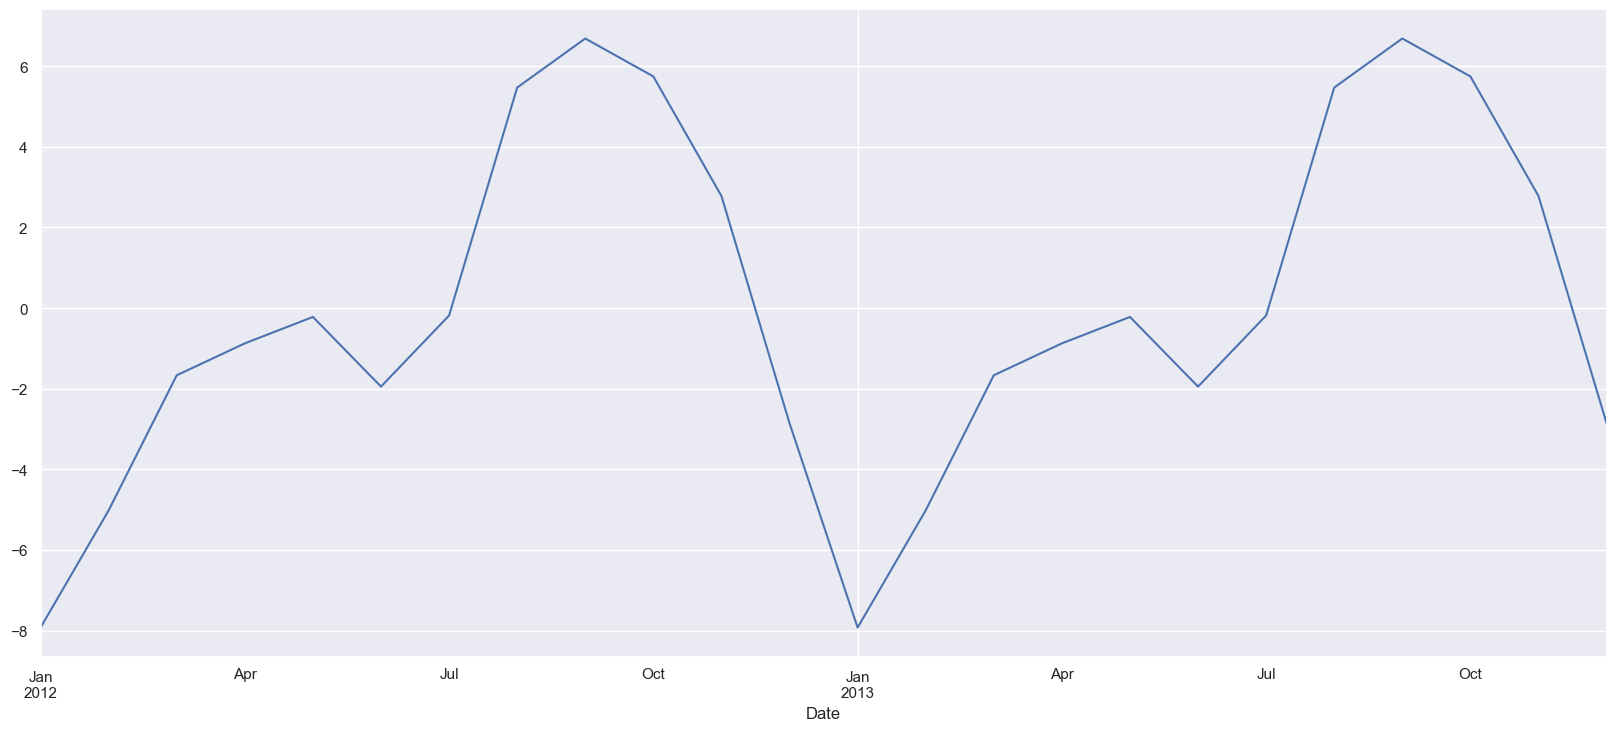

<Figure size 800x800 with 0 Axes>

In [133]:
##For better Observation of Seasonality
decomposed_series.seasonal['2012':'2013'].plot()
fig = plt.figure(figsize=(8,8))

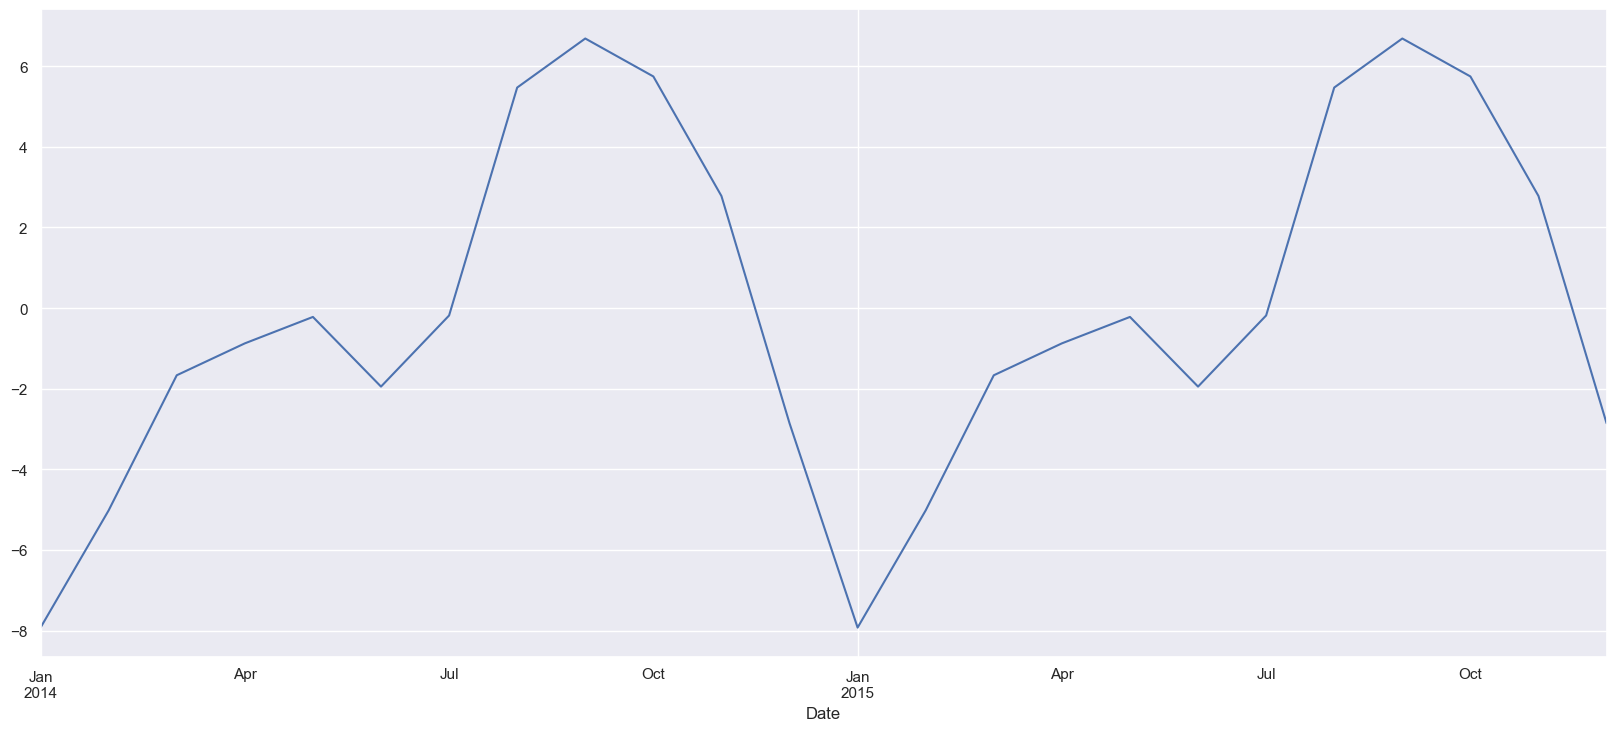

<Figure size 800x800 with 0 Axes>

In [134]:
##For better Observation of Seasonality
decomposed_series.seasonal['2014':'2015'].plot()
fig = plt.figure(figsize=(8,8))

#### Observing the above seasonality , we can say that there is a spike around the month of september

In [135]:
close_data = df['Close']

In [136]:
df['MA10'] = df['Close'].rolling(window=10).mean()        # 10-day Moving Average
df['MA30'] = df['Close'].rolling(window=30).mean()         # 30-day Moving Average
df['Volatility'] = df['Close'].rolling(window=10).std()   # 10-day Volatility (Std Dev)

In [137]:
# Moving averages help identify smoothed price trends.
# Volatility (standard deviation) helps capture market risk or fluctuations.

In [138]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df_scaled

,Open,High,Low,Close,Adj Close,Volume,Year,MA10,MA30,Volatility
Date,,,,,,,,,,
2012-01-03,-1.351697,-1.353253,-1.340019,-1.344666,-1.311193,0.342933,-1.528793,NaN,NaN,NaN
2012-01-04,-1.349998,-1.347136,-1.339221,-1.338422,-1.305989,0.117642,-1.528793,NaN,NaN,NaN
2012-01-05,-1.335988,-1.336277,-1.329557,-1.325455,-1.295181,0.177690,-1.528793,NaN,NaN,NaN
2012-01-06,-1.322345,-1.324493,-1.310885,-1.313109,-1.284891,0.428738,-1.528793,NaN,NaN,NaN
2012-01-09,-1.306126,-1.310463,-1.304813,-1.315001,-1.286468,0.833055,-1.528793,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2019-12-23,3.047729,3.072309,3.088846,3.109983,3.100569,-0.744309,1.529010,3.011949,2.927475,1.735000
2019-12-24,3.130152,3.084879,3.139732,3.115323,3.105684,-1.011747,1.529010,3.043570,2.942580,1.430927
2019-12-26,3.132728,3.184852,3.175252,3.226861,3.212528,-0.773410,1.529010,3.081900,2.961708,1.671656


In [139]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [140]:
#Train-Test Split

# We hold out the last 30 days of data for testing (forecast target)
train = close_data[:-30]
test = close_data[-30:]

In [141]:
#train is used for model training; test represents the next 30 days we want to forecast and evaluate against.

In [142]:
# Model 1: ARIMA

print("Training ARIMA...")
arima_model = ARIMA(train, order=(5, 1, 0))       # p=5, d=1, q=0
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=30)

arima_pred

Training ARIMA...


1981    262.566524
1982    262.662823
1983    262.763636
1984    262.752632
1985    262.708347
1986    262.708691
1987    262.716137
1988    262.718369
1989    262.716418
1990    262.715339
1991    262.715637
1992    262.715935
1993    262.715919
1994    262.715828
1995    262.715813
1996    262.715832
1997    262.715840
1998    262.715836
1999    262.715833
2000    262.715834
2001    262.715834
2002    262.715834
2003    262.715834
2004    262.715834
2005    262.715834
2006    262.715834
2007    262.715834
2008    262.715834
2009    262.715834
2010    262.715834
Name: predicted_mean, dtype: float64

In [143]:
# ARIMA models the series using autoregression (p), differencing (d), and moving average (q).

# It’s suitable for non-seasonal univariate forecasting.

In [144]:
# Model 2: SARIMA

print("Training SARIMA...")
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.forecast(steps=30)

sarima_pred

Training SARIMA...


1981    262.481136
1982    262.729527
1983    263.038623
1984    263.192247
1985    263.098876
1986    263.508133
1987    263.612992
1988    263.915291
1989    264.026835
1990    264.025735
1991    264.054380
1992    264.162004
1993    264.134814
1994    264.169127
1995    264.443539
1996    264.487580
1997    264.467104
1998    264.825195
1999    264.937887
2000    265.191942
2001    265.300026
2002    265.274854
2003    265.279904
2004    265.404467
2005    265.396950
2006    265.412705
2007    265.698613
2008    265.730298
2009    265.719857
2010    266.069692
Name: predicted_mean, dtype: float64

In [145]:
# SARIMA includes both trend and seasonality components. (P,D,Q,s) = seasonal parts.

# Useful for capturing annual or monthly cyclic behaviors in financial time series.

In [146]:
# Model 3: Random Forest

print("Training Random Forest...")
rf_df = df[['Close', 'MA10', 'MA30', 'Volatility']].dropna()

X = rf_df[['MA10', 'MA30', 'Volatility']]
y = rf_df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.1)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test[-30:])

rf_pred

Training Random Forest...


array([225.25599738, 225.09399818, 225.39119712, 225.29499761,
       225.29499761, 225.29499761, 225.29499761, 225.29499761,
       225.29499761, 225.29499761, 225.29499761, 225.29499761,
       225.29499761, 225.30289769, 225.24049783, 225.39119712,
       225.24049783, 224.63699727, 222.93389851, 223.97970145,
       219.32159953, 219.51659953, 220.59879939, 221.3661995 ,
       221.3661995 , 221.93629989, 224.02500144, 223.49410072,
       223.97970145, 223.97970145])

In [147]:
# Random Forest is an ensemble model that builds multiple decision trees.

# It captures nonlinear patterns and interactions between features like MA10, MA30, and volatility.

In [148]:
# Model 4: XGBoost

print("Training XGBoost...")
xgb_model = XGBRegressor(n_estimators=100, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test[-30:])

xgb_pred 

Training XGBoost...


array([225.60712, 225.05078, 225.6343 , 226.93427, 225.51483, 226.19972,
       226.07883, 226.27843, 225.82472, 225.82472, 225.51483, 226.43742,
       226.43742, 226.22995, 226.29237, 225.6343 , 226.29237, 224.7918 ,
       216.8259 , 223.39249, 213.89691, 213.89691, 221.6269 , 223.08789,
       223.08789, 223.08789, 225.13963, 223.1063 , 223.39249, 223.39249],
      dtype=float32)

In [149]:
# XGBoost is a powerful tree-based boosting algorithm.

# It often performs better than traditional models on tabular datasets due to its regularization and handling of missing data.

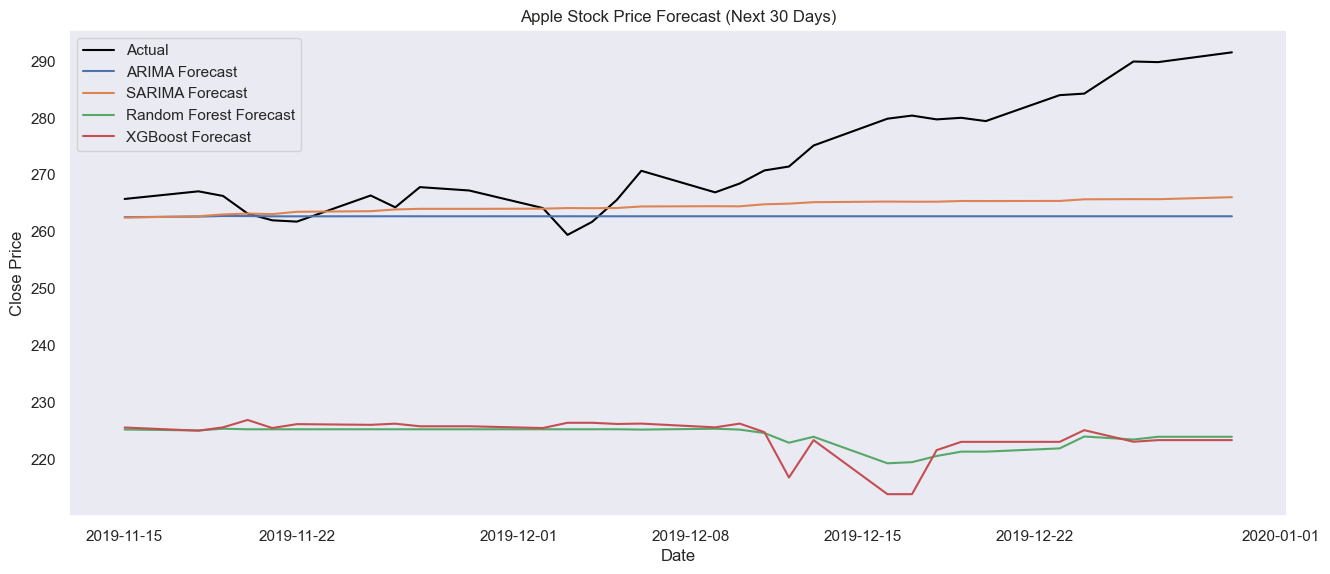

In [150]:
# Visualization
# ================================
plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, label='Actual', color='black')
plt.plot(test.index, arima_pred, label='ARIMA Forecast')
plt.plot(test.index, sarima_pred, label='SARIMA Forecast')
plt.plot(test.index, rf_pred, label='Random Forest Forecast')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast')
plt.title('Apple Stock Price Forecast (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

In [151]:
# Plots actual vs. predicted prices for each model.

# Helps visually compare the forecasting performance of different models.